<a href="https://colab.research.google.com/github/Niloy-Bhuiyan/Programming-in-Python-FinalTerm/blob/main/seoul_bike_sharing_final_boss_23_50020_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seoul Bike Sharing Demand Data Analysis Project

**Student name:** Nurul Azam Bhuiyan  
**Student ID:** 23-50020-1  
**Course:** Data Analysis with Pandas, NumPy, and Matplotlib  
**Project title:** How Weather, Time, and Holidays Affect Public Bike Rental Demand in Seoul  
**Dataset:** Seoul Bike Sharing Demand  
**Dataset source:** UCI Machine Learning Repository  
**Dataset link:** https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand  

## Project objective

The goal of this project is to analyze hourly public bike rental demand in Seoul and understand how time, season, weather, holidays, and service availability affect the number of rented bikes.

This dataset has a clear real life story. In a city bike sharing system, bikes must be available at the right time and under the right conditions. If demand is high but enough bikes are not prepared, users may face problems. If too many bikes are kept ready during low demand periods, resources are wasted. This analysis helps understand when bike demand becomes high, when it becomes low, and which factors are related to those changes.

## Analytical questions

1. Which time related factors, such as hour, month, season, and weekend status, have the highest bike rental demand?
2. How do weather factors such as temperature, humidity, rainfall, snowfall, and solar radiation relate to bike rental demand?
3. Are there unusual high demand or low demand hours, and what do those patterns tell us?

## Why these questions matter

These questions matter because public bike sharing supports urban mobility, reduces pressure on public transport, and can help cities plan better. A demand analysis can help bike sharing operators prepare enough bikes during busy periods and understand how weather, holidays, and service availability affect usage.


# Section 1: Import required libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# These are standard Python libraries used only to download and extract the dataset.
import urllib.request
import zipfile

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)

# A small custom color palette for cleaner looking Matplotlib charts.
chartColors = [
    "#264653", "#2A9D8F", "#E9C46A", "#F4A261",
    "#E76F51", "#6D597A", "#457B9D", "#8AB17D",
    "#B56576", "#5E548E", "#BC6C25", "#577590"
]


# Section 2: Download and load the dataset from UCI

In [ ]:


dataUrl = "https://archive.ics.uci.edu/static/public/560/seoul%2Bbike%2Bsharing%2Bdemand.zip"
zipFileName = "seoulBikeSharingDemand.zip"

urllib.request.urlretrieve(dataUrl, zipFileName)

with zipfile.ZipFile(zipFileName, "r") as zipFolder:
    zipFolder.extractall()

bikeRawData = pd.read_csv("SeoulBikeData.csv", encoding="cp949")

print("Dataset loaded successfully.")
print("Original dataset shape:")
print(bikeRawData.shape)

print("\nFirst 5 rows:")
display(bikeRawData.head())

Dataset loaded successfully.
Original dataset shape:
(8760, 14)

First 5 rows:


,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## Data understanding

Before cleaning or analysis, I first inspect the dataset structure. This helps me understand the number of rows and columns, data types, missing values, duplicate rows, and the general range of numerical values.


# Section 3: Basic data understanding

In [ ]:


print("Column names:")
print(bikeRawData.columns.tolist())

print("\nDataset shape:")
print(bikeRawData.shape)

print("\nData types:")
print(bikeRawData.dtypes)

print("\nSample rows:")
display(bikeRawData.head())

print("\nSummary statistics:")
display(bikeRawData.describe())

print("\nMissing value count:")
missingValues = bikeRawData.isnull().sum()
display(missingValues)

print("\nMissing value percentage:")
missingPercent = (bikeRawData.isnull().sum() / len(bikeRawData)) * 100
display(missingPercent.round(2))

print("\nDuplicate row count:")
print(bikeRawData.duplicated().sum())

print("\nData understanding note:")
print("The dataset has hourly records, weather variables, season, holiday status, and functioning day status.")
print("This structure is suitable for time based, weather based, subgroup, and outlier analysis.")

Column names:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(캜)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(캜)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']

Dataset shape:
(8760, 14)

Data types:
Date                         object
Rented Bike Count             int64
Hour                          int64
Temperature(캜)              float64
Humidity(%)                   int64
Wind speed (m/s)            float64
Visibility (10m)              int64
Dew point temperature(캜)    float64
Solar Radiation (MJ/m2)     float64
Rainfall(mm)                float64
Snowfall (cm)               float64
Seasons                      object
Holiday                      object
Functioning Day              object
dtype: object

Sample rows:


,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes



Summary statistics:


,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000



Missing value count:


,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(캜),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(캜),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0



Missing value percentage:


,0
Date,0.0
Rented Bike Count,0.0
Hour,0.0
Temperature(캜),0.0
Humidity(%),0.0
Wind speed (m/s),0.0
Visibility (10m),0.0
Dew point temperature(캜),0.0
Solar Radiation (MJ/m2),0.0
Rainfall(mm),0.0



Duplicate row count:
0

Data understanding note:
The dataset has hourly records, weather variables, season, holiday status, and functioning day status.
This structure is suitable for time based, weather based, subgroup, and outlier analysis.


## Data cleaning and preparation

The cleaning decisions below are simple and explainable. I did not remove data without a reason. Every major step includes a short justification.


# Section 4: Cleaning step 1
# Rename columns to simple camelCase names

In [ ]:


bikeData = bikeRawData.copy()

# Remove extra spaces from original column names first.
bikeData.columns = bikeData.columns.str.strip()

newColumnNames = [
    "date",
    "rentedBikeCount",
    "hour",
    "temperature",
    "humidity",
    "windSpeed",
    "visibility",
    "dewPointTemperature",
    "solarRadiation",
    "rainfall",
    "snowfall",
    "season",
    "holiday",
    "functioningDay"
]

# Safety check before position based renaming.
# This prevents silent mistakes if the dataset source changes its number of columns.
if len(bikeData.columns) != len(newColumnNames):
    raise ValueError("Column count changed. Please check the original dataset columns before renaming.")

bikeData.columns = newColumnNames

print("Updated column names:")
print(bikeData.columns.tolist())

print("\nJustification:")
print("The original column names had spaces, brackets, and special symbols.")
print("I renamed them to simple camelCase names so the code is easier to write and explain.")
print("I also added a column count check so position based renaming does not silently mislabel the data.")

Updated column names:
['date', 'rentedBikeCount', 'hour', 'temperature', 'humidity', 'windSpeed', 'visibility', 'dewPointTemperature', 'solarRadiation', 'rainfall', 'snowfall', 'season', 'holiday', 'functioningDay']

Justification:
The original column names had spaces, brackets, and special symbols.
I renamed them to simple camelCase names so the code is easier to write and explain.
I also added a column count check so position based renaming does not silently mislabel the data.



# Section 5: Cleaning step 2
# Remove duplicate rows

In [ ]:

rowsBeforeDuplicateCheck = len(bikeData)
bikeData = bikeData.drop_duplicates()
rowsAfterDuplicateCheck = len(bikeData)

print("Rows before duplicate removal:", rowsBeforeDuplicateCheck)
print("Rows after duplicate removal:", rowsAfterDuplicateCheck)
print("Duplicate rows removed:", rowsBeforeDuplicateCheck - rowsAfterDuplicateCheck)

print("\nJustification:")
print("Duplicate rows can count the same hour more than once.")
print("Removing exact duplicates keeps the hourly demand analysis reliable.")

Rows before duplicate removal: 8760
Rows after duplicate removal: 8760
Duplicate rows removed: 0

Justification:
Duplicate rows can count the same hour more than once.
Removing exact duplicates keeps the hourly demand analysis reliable.



# Section 6: Cleaning step 3
# Convert date and numeric columns to proper data types

In [ ]:


bikeData["date"] = pd.to_datetime(bikeData["date"], dayfirst=True, errors="coerce")

numberColumns = [
    "rentedBikeCount", "hour", "temperature", "humidity", "windSpeed",
    "visibility", "dewPointTemperature", "solarRadiation", "rainfall", "snowfall"
]

for columnName in numberColumns:
    bikeData[columnName] = pd.to_numeric(bikeData[columnName], errors="coerce")

print("Data types after conversion:")
print(bikeData.dtypes)

print("\nMissing values after conversion:")
display(bikeData.isnull().sum())

print("\nJustification:")
print("Date must be a datetime value so month, day, and weekday can be created.")
print("Numerical columns must be numeric so grouping, averages, correlation, and NumPy calculations work correctly.")

Data types after conversion:
date                   datetime64[ns]
rentedBikeCount                 int64
hour                            int64
temperature                   float64
humidity                        int64
windSpeed                     float64
visibility                      int64
dewPointTemperature           float64
solarRadiation                float64
rainfall                      float64
snowfall                      float64
season                         object
holiday                        object
functioningDay                 object
dtype: object

Missing values after conversion:


,0
date,0
rentedBikeCount,0
hour,0
temperature,0
humidity,0
windSpeed,0
visibility,0
dewPointTemperature,0
solarRadiation,0
rainfall,0



Justification:
Date must be a datetime value so month, day, and weekday can be created.
Numerical columns must be numeric so grouping, averages, correlation, and NumPy calculations work correctly.



# Section 7: Cleaning step 4
# Standardize text columns and check expected categories

In [ ]:


bikeData["season"] = bikeData["season"].astype(str).str.strip().str.title()
bikeData["holiday"] = bikeData["holiday"].astype(str).str.strip().str.title()
bikeData["functioningDay"] = bikeData["functioningDay"].astype(str).str.strip().str.title()

print("Season values:")
print(bikeData["season"].unique())

print("\nHoliday values:")
print(bikeData["holiday"].unique())

print("\nFunctioning day values:")
print(bikeData["functioningDay"].unique())

expectedFunctioningValues = ["Yes", "No"]
unexpectedFunctioningValues = []

for value in bikeData["functioningDay"].unique():
    if value not in expectedFunctioningValues:
        unexpectedFunctioningValues.append(value)

print("\nUnexpected functioning day values:")
print(unexpectedFunctioningValues)

print("\nJustification:")
print("Text values were standardized to avoid grouping problems caused by extra spaces or inconsistent capitalization.")
print("The functioning day check confirms that the later service open filter will work correctly.")

Season values:
['Winter' 'Spring' 'Summer' 'Autumn']

Holiday values:
['No Holiday' 'Holiday']

Functioning day values:
['Yes' 'No']

Unexpected functioning day values:
[]

Justification:
Text values were standardized to avoid grouping problems caused by extra spaces or inconsistent capitalization.
The functioning day check confirms that the later service open filter will work correctly.



# Section 8: Cleaning step 5
# Handle missing and invalid values

In [ ]:


rowsBeforeMissingCheck = len(bikeData)

# Main analysis needs a valid date and rented bike count.
bikeData = bikeData.dropna(subset=["date", "rentedBikeCount"])

# Rental count cannot be negative.
bikeData = bikeData[bikeData["rentedBikeCount"] >= 0]

# Hour should be from 0 to 23.
bikeData = bikeData[(bikeData["hour"] >= 0) & (bikeData["hour"] <= 23)]

rowsAfterMissingCheck = len(bikeData)

print("Rows before missing and invalid value handling:", rowsBeforeMissingCheck)
print("Rows after missing and invalid value handling:", rowsAfterMissingCheck)
print("Rows removed:", rowsBeforeMissingCheck - rowsAfterMissingCheck)

print("\nMissing values now:")
display(bikeData.isnull().sum())

print("\nJustification:")
print("Rows without date or rented bike count cannot answer the main questions.")
print("Negative rented bike counts and invalid hours would be impossible values, so they are removed if found.")

Rows before missing and invalid value handling: 8760
Rows after missing and invalid value handling: 8760
Rows removed: 0

Missing values now:


,0
date,0
rentedBikeCount,0
hour,0
temperature,0
humidity,0
windSpeed,0
visibility,0
dewPointTemperature,0
solarRadiation,0
rainfall,0



Justification:
Rows without date or rented bike count cannot answer the main questions.
Negative rented bike counts and invalid hours would be impossible values, so they are removed if found.



# Section 9: Cleaning step 6
# Separate service open hours from service closed hours

In [ ]:


bikeData["serviceStatus"] = "Service Open"
bikeData.loc[bikeData["functioningDay"] != "Yes", "serviceStatus"] = "Service Closed"

workingBikeData = bikeData[bikeData["functioningDay"] == "Yes"].copy()

print("All rows:", len(bikeData))
print("Rows where service was open:", len(workingBikeData))
print("Rows where service was closed:", len(bikeData) - len(workingBikeData))

print("\nService status count:")
display(bikeData["serviceStatus"].value_counts())

print("\nJustification:")
print("When the service is closed, rented bike count becomes zero because bikes were unavailable.")
print("For demand analysis, I mainly use service open rows so closed service hours do not create misleading low demand.")

All rows: 8760
Rows where service was open: 8465
Rows where service was closed: 295

Service status count:


,count
serviceStatus,
Service Open,8465
Service Closed,295



Justification:
When the service is closed, rented bike count becomes zero because bikes were unavailable.
For demand analysis, I mainly use service open rows so closed service hours do not create misleading low demand.


## Feature engineering

This section creates new columns from existing data. These features help answer the analytical questions about time, weather, and unusual demand patterns.


# Section 10: Feature engineering

In [ ]:


# Feature 1: Year
workingBikeData["year"] = workingBikeData["date"].dt.year

# Feature 2: Month number
workingBikeData["monthNumber"] = workingBikeData["date"].dt.month

# Feature 3: Month name
workingBikeData["monthName"] = workingBikeData["date"].dt.month_name()

# Feature 4: Day name
workingBikeData["dayName"] = workingBikeData["date"].dt.day_name()

# Feature 5: Weekend or weekday
workingBikeData["weekendStatus"] = "Weekday"
workingBikeData.loc[workingBikeData["date"].dt.dayofweek >= 5, "weekendStatus"] = "Weekend"

# Feature 6: Time period of the day
workingBikeData["timePeriod"] = "Night"
workingBikeData.loc[(workingBikeData["hour"] >= 6) & (workingBikeData["hour"] < 12), "timePeriod"] = "Morning"
workingBikeData.loc[(workingBikeData["hour"] >= 12) & (workingBikeData["hour"] < 17), "timePeriod"] = "Afternoon"
workingBikeData.loc[(workingBikeData["hour"] >= 17) & (workingBikeData["hour"] < 22), "timePeriod"] = "Evening"

# Feature 7: Weather condition based on rain and snow
workingBikeData["weatherCondition"] = "Dry"
workingBikeData.loc[(workingBikeData["rainfall"] > 0) & (workingBikeData["snowfall"] == 0), "weatherCondition"] = "Rainy"
workingBikeData.loc[(workingBikeData["rainfall"] == 0) & (workingBikeData["snowfall"] > 0), "weatherCondition"] = "Snowy"
workingBikeData.loc[(workingBikeData["rainfall"] > 0) & (workingBikeData["snowfall"] > 0), "weatherCondition"] = "Rain And Snow"

# Feature 8: Temperature group
workingBikeData["temperatureGroup"] = "Cold"
workingBikeData.loc[(workingBikeData["temperature"] >= 10) & (workingBikeData["temperature"] < 25), "temperatureGroup"] = "Comfortable"
workingBikeData.loc[workingBikeData["temperature"] >= 25, "temperatureGroup"] = "Hot"

# Feature 9: Demand level using NumPy percentiles
lowDemandLine = np.percentile(workingBikeData["rentedBikeCount"], 33)
highDemandLine = np.percentile(workingBikeData["rentedBikeCount"], 66)

workingBikeData["demandLevel"] = "Medium Demand"
workingBikeData.loc[workingBikeData["rentedBikeCount"] <= lowDemandLine, "demandLevel"] = "Low Demand"
workingBikeData.loc[workingBikeData["rentedBikeCount"] >= highDemandLine, "demandLevel"] = "High Demand"


# Feature 10: Simple weather comfort score
# This is a simple custom score, not a scientific formula.
# Formula:
# weatherComfortScore = 100 - temperaturePenalty - humidityPenalty - rainPenalty - snowPenalty

temperaturePenalty = abs(workingBikeData["temperature"] - 22) * 2
humidityPenalty = workingBikeData["humidity"] * 0.2
rainPenalty = workingBikeData["rainfall"] * 10
snowPenalty = workingBikeData["snowfall"] * 10

workingBikeData["weatherComfortScore"] = 100 - temperaturePenalty - humidityPenalty - rainPenalty - snowPenalty

print("New columns created:")
print([
    "year", "monthNumber", "monthName", "dayName", "weekendStatus",
    "timePeriod", "weatherCondition", "temperatureGroup",
    "demandLevel", "weatherComfortScore"
])

print("\nSample after feature engineering:")
display(workingBikeData[[
    "date", "hour", "rentedBikeCount", "season", "monthName", "dayName",
    "weekendStatus", "timePeriod", "weatherCondition", "temperatureGroup",
    "demandLevel", "weatherComfortScore"
]].head())

print("\nFeature engineering justification:")
print("Year, month, and dayName support date based analysis.")
print("Weekend status helps compare weekday and weekend demand.")
print("Time period helps explain daily travel patterns.")
print("Weather condition and temperature group help compare demand under different weather situations.")
print("Demand level is created with NumPy percentiles and helps identify low, medium, and high demand periods.")
print("Weather comfort score is a simple custom feature to combine temperature, humidity, rain, and snow into one understandable score.")

New columns created:
['year', 'monthNumber', 'monthName', 'dayName', 'weekendStatus', 'timePeriod', 'weatherCondition', 'temperatureGroup', 'demandLevel', 'weatherComfortScore']

Sample after feature engineering:


,date,hour,rentedBikeCount,season,monthName,dayName,weekendStatus,timePeriod,weatherCondition,temperatureGroup,demandLevel,weatherComfortScore
0,2017-12-01,0,254,Winter,December,Friday,Weekday,Night,Dry,Cold,Low Demand,38.2
1,2017-12-01,1,204,Winter,December,Friday,Weekday,Night,Dry,Cold,Low Demand,37.4
2,2017-12-01,2,173,Winter,December,Friday,Weekday,Night,Dry,Cold,Low Demand,36.2
3,2017-12-01,3,107,Winter,December,Friday,Weekday,Night,Dry,Cold,Low Demand,35.6
4,2017-12-01,4,78,Winter,December,Friday,Weekday,Night,Dry,Cold,Low Demand,36.8



Feature engineering justification:
Year, month, and dayName support date based analysis.
Weekend status helps compare weekday and weekend demand.
Time period helps explain daily travel patterns.
Weather condition and temperature group help compare demand under different weather situations.
Demand level is created with NumPy percentiles and helps identify low, medium, and high demand periods.
Weather comfort score is a simple custom feature to combine temperature, humidity, rain, and snow into one understandable score.


## Data analysis

This section performs more than the required number of analysis operations. It includes subgroup comparisons, relationship analysis, outlier analysis, and meaningful NumPy use.


# Section 11: Analysis 1
# Overall summary of the cleaned data

In [ ]:


print("Total records in original data:", len(bikeRawData))
print("Total records after cleaning:", len(bikeData))
print("Records used for main demand analysis:", len(workingBikeData))
print("Number of columns in main analysis data:", workingBikeData.shape[1])

print("\nMain numeric summary:")
display(workingBikeData[[
    "rentedBikeCount", "temperature", "humidity", "windSpeed",
    "visibility", "solarRadiation", "rainfall", "snowfall"
]].describe())

Total records in original data: 8760
Total records after cleaning: 8760
Records used for main demand analysis: 8465
Number of columns in main analysis data: 25

Main numeric summary:


,rentedBikeCount,temperature,humidity,windSpeed,visibility,solarRadiation,rainfall,snowfall
count,8465.000000,8465.000000,8465.000000,8465.000000,8465.000000,8465.000000,8465.00000,8465.000000
mean,729.156999,12.771057,58.147194,1.725883,1433.873479,0.567868,0.14912,0.077685
std,642.351166,12.104375,20.484839,1.034281,609.051229,0.868245,1.12554,0.444063
min,2.000000,-17.800000,0.000000,0.000000,27.000000,0.000000,0.00000,0.000000
25%,214.000000,3.000000,42.000000,0.900000,935.000000,0.000000,0.00000,0.000000
50%,542.000000,13.500000,57.000000,1.500000,1690.000000,0.010000,0.00000,0.000000
75%,1084.000000,22.700000,74.000000,2.300000,2000.000000,0.930000,0.00000,0.000000
max,3556.000000,39.400000,98.000000,7.400000,2000.000000,3.520000,35.00000,8.800000



# Section 12: Analysis 2
# Rental demand by season
# Subgroup comparison 1

In [ ]:


seasonDemand = workingBikeData.groupby("season")["rentedBikeCount"].agg(["count", "mean", "median", "max"])
seasonDemand = seasonDemand.sort_values("mean", ascending=False)

print("Rental demand by season:")
display(seasonDemand.round(2))

Rental demand by season:


,count,mean,median,max
season,,,,
Summer,2208,1034.07,905.5,3556
Autumn,1937,924.11,856.0,3298
Spring,2160,746.25,599.0,3251
Winter,2160,225.54,203.0,937



# Section 13: Analysis 3
# Rental demand by month
# This directly supports the first analytical question.

In [ ]:


monthDemand = workingBikeData.groupby(["monthNumber", "monthName"])["rentedBikeCount"].agg(["count", "mean", "median", "max"])
monthDemand = monthDemand.sort_values("mean", ascending=False)

print("Rental demand by month:")
display(monthDemand.round(2))

Rental demand by month:


,,count,mean,median,max
monthNumber,monthName,,,,
6,June,720,1245.68,1144.5,3556
9,September,624,1079.51,1018.0,3298
7,July,744,987.18,829.5,3196
5,May,720,982.07,933.5,3251
10,October,665,978.46,961.0,2857
8,August,744,876.19,732.5,2836
4,April,696,753.20,681.0,2807
11,November,648,718.70,698.0,2357
3,March,744,511.55,460.0,2100



# Section 14: Analysis 4
# Rental demand by hour

In [ ]:


hourDemand = workingBikeData.groupby("hour")["rentedBikeCount"].agg(["count", "mean", "median", "max"])
hourDemand = hourDemand.sort_index()

print("Rental demand by hour:")
display(hourDemand.round(2))

busiestHour = hourDemand["mean"].idxmax()
quietestHour = hourDemand["mean"].idxmin()

print("\nBusiest average hour:", busiestHour)
print("Quietest average hour:", quietestHour)

Rental demand by hour:


,count,mean,median,max
hour,,,,
0,352,561.46,531.5,1394
1,352,441.92,411.5,1088
2,352,312.77,277.0,1254
3,352,210.84,183.5,644
4,352,137.49,123.5,421
5,352,144.22,136.5,383
6,352,298.18,245.0,807
7,353,626.61,443.0,1629
8,353,1050.23,767.0,2495



Busiest average hour: 18
Quietest average hour: 4



# Section 15: Analysis 5
# Weekday versus weekend demand
# Subgroup comparison 2

In [ ]:


weekendDemand = workingBikeData.groupby("weekendStatus")["rentedBikeCount"].agg(["count", "mean", "median", "max"])
weekendDemand = weekendDemand.sort_values("mean", ascending=False)

print("Weekday versus weekend rental demand:")
display(weekendDemand.round(2))

Weekday versus weekend rental demand:


,count,mean,median,max
weekendStatus,,,,
Weekday,6024,748.11,564.5,3556
Weekend,2441,682.38,483.0,2514



# Section 16: Analysis 6
# Holiday versus non holiday demand
# Subgroup comparison 3

In [ ]:


holidayDemand = workingBikeData.groupby("holiday")["rentedBikeCount"].agg(["count", "mean", "median", "max"])
holidayDemand = holidayDemand.sort_values("mean", ascending=False)

print("Holiday versus non holiday rental demand:")
display(holidayDemand.round(2))

Holiday versus non holiday rental demand:


,count,mean,median,max
holiday,,,,
No Holiday,8057,739.28,561.0,3556
Holiday,408,529.15,259.0,2400



# Section 17: Analysis 7
# Rental demand by weather condition
# Subgroup comparison 4

In [ ]:


weatherDemand = workingBikeData.groupby("weatherCondition")["rentedBikeCount"].agg(["count", "mean", "median", "max"])
weatherDemand = weatherDemand.sort_values("mean", ascending=False)

print("Rental demand by weather condition:")
display(weatherDemand.round(2))

Rental demand by weather condition:


,count,mean,median,max
weatherCondition,,,,
Dry,7534,797.28,643.0,3556
Snowy,415,191.16,151.0,1524
Rainy,488,171.39,71.5,2598
Rain And Snow,28,95.29,61.5,329



# Section 18: Analysis 8
# Rental demand by temperature group
# Subgroup comparison 5


In [ ]:

temperatureDemand = workingBikeData.groupby("temperatureGroup")["rentedBikeCount"].agg(["count", "mean", "median", "max"])
temperatureDemand = temperatureDemand.sort_values("mean", ascending=False)

print("Rental demand by temperature group:")
display(temperatureDemand.round(2))

Rental demand by temperature group:


,count,mean,median,max
temperatureGroup,,,,
Hot,1519,1194.89,1064.0,3418
Comfortable,3395,933.89,881.0,3556
Cold,3551,334.19,242.0,2202



# Section 19: Analysis 9
# Rental demand by time period

In [ ]:


timePeriodDemand = workingBikeData.groupby("timePeriod")["rentedBikeCount"].agg(["count", "mean", "median", "max"])
timePeriodDemand = timePeriodDemand.sort_values("mean", ascending=False)

print("Rental demand by time period:")
display(timePeriodDemand.round(2))

Rental demand by time period:


,count,mean,median,max
timePeriod,,,,
Evening,1765,1227.76,1249.0,3556
Afternoon,1765,817.13,790.0,2479
Morning,2117,635.16,561.0,2495
Night,2818,432.38,255.0,2309



# Section 20: Analysis 10
# Relationship analysis between weather variables and rented bike count


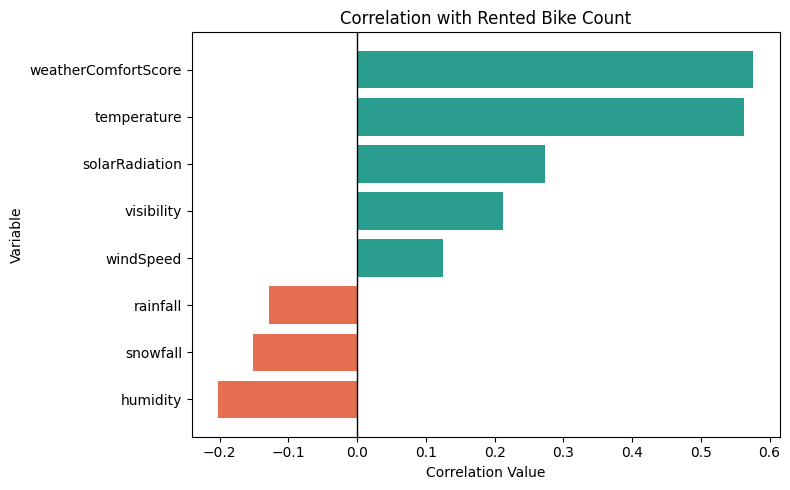

Chart interpretation:
This chart shows which weather variables have positive or negative relationships with rented bike count.
Temperature has the strongest positive relationship among the original weather variables.
Humidity, rainfall, and snowfall have negative relationships with bike rental demand.


In [37]:


correlationChartData = relationshipTable.sort_values("correlationWithRentalCount")

barColors = []

for value in correlationChartData["correlationWithRentalCount"]:
    if value >= 0:
        barColors.append("#2A9D8F")
    else:
        barColors.append("#E76F51")

plt.figure(figsize=(8, 5))
plt.barh(
    correlationChartData["variable"],
    correlationChartData["correlationWithRentalCount"],
    color=barColors
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation with Rented Bike Count")
plt.xlabel("Correlation Value")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("chartWeatherCorrelation.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This chart shows which weather variables have positive or negative relationships with rented bike count.")
print("Temperature has the strongest positive relationship among the original weather variables.")
print("Humidity, rainfall, and snowfall have negative relationships with bike rental demand.")

In [ ]:


weatherColumns = [
    "temperature", "humidity", "windSpeed", "visibility",
    "solarRadiation", "rainfall", "snowfall", "weatherComfortScore"
]

relationshipRows = []

for columnName in weatherColumns:
    correlation = workingBikeData[columnName].corr(workingBikeData["rentedBikeCount"])
    relationshipRows.append([columnName, correlation])

relationshipTable = pd.DataFrame(relationshipRows, columns=["variable", "correlationWithRentalCount"])
relationshipTable = relationshipTable.sort_values("correlationWithRentalCount", ascending=False)

print("Relationship between weather variables and rented bike count:")
display(relationshipTable.round(4))

originalRelationshipTable = relationshipTable[relationshipTable["variable"] != "weatherComfortScore"]
strongestOriginalWeatherVariable = originalRelationshipTable.iloc[0]["variable"]
strongestOriginalWeatherCorrelation = originalRelationshipTable.iloc[0]["correlationWithRentalCount"]

comfortScoreCorrelation = relationshipTable[relationshipTable["variable"] == "weatherComfortScore"]["correlationWithRentalCount"].iloc[0]

print("\nStrongest original weather variable:", strongestOriginalWeatherVariable)
print("Correlation:", round(strongestOriginalWeatherCorrelation, 4))
print("Custom weather comfort score correlation:", round(comfortScoreCorrelation, 4))

print("\nInterpretation guide:")
print("A positive value means the variable tends to increase when rental count increases.")
print("A negative value means the variable tends to decrease when rental count increases.")
print("A value near zero means weak linear relationship.")
print("Correlation does not prove causation.")

Relationship between weather variables and rented bike count:


,variable,correlationWithRentalCount
7,weatherComfortScore,0.5763
0,temperature,0.5627
4,solarRadiation,0.2739
3,visibility,0.2123
2,windSpeed,0.1250
5,rainfall,-0.1286
6,snowfall,-0.1516
1,humidity,-0.2020



Strongest original weather variable: temperature
Correlation: 0.5627
Custom weather comfort score correlation: 0.5763

Interpretation guide:
A positive value means the variable tends to increase when rental count increases.
A negative value means the variable tends to decrease when rental count increases.
A value near zero means weak linear relationship.
Correlation does not prove causation.



# Section 21: Analysis 11
# Top 10 highest demand records

In [ ]:


topDemandHours = workingBikeData.sort_values("rentedBikeCount", ascending=False).head(10)

print("Top 10 highest demand hours:")
display(topDemandHours[[
    "date", "hour", "rentedBikeCount", "season", "temperature",
    "humidity", "rainfall", "snowfall", "holiday", "weekendStatus"
]])

Top 10 highest demand hours:


,date,hour,rentedBikeCount,season,temperature,humidity,rainfall,snowfall,holiday,weekendStatus
4818,2018-06-19,18,3556,Summer,24.1,57,0.0,0.0,No Holiday,Weekday
4866,2018-06-21,18,3418,Summer,27.8,43,0.0,0.0,No Holiday,Weekday
4650,2018-06-12,18,3404,Summer,24.9,53,0.0,0.0,No Holiday,Weekday
4842,2018-06-20,18,3384,Summer,27.0,55,0.0,0.0,No Holiday,Weekday
4458,2018-06-04,18,3380,Summer,24.4,48,0.0,0.0,No Holiday,Weekday
4890,2018-06-22,18,3365,Summer,29.3,27,0.0,0.0,No Holiday,Weekday
4554,2018-06-08,18,3309,Summer,26.2,54,0.0,0.0,No Holiday,Weekday
6810,2018-09-10,18,3298,Autumn,25.9,42,0.0,0.0,No Holiday,Weekday
6978,2018-09-17,18,3277,Autumn,25.3,56,0.0,0.0,No Holiday,Weekday
6858,2018-09-12,18,3256,Autumn,27.0,44,0.0,0.0,No Holiday,Weekday



# Section 22: Analysis 12
# Top 10 lowest demand records while service was open
# This directly supports the third analytical question.

In [ ]:


lowestDemandHours = workingBikeData.sort_values("rentedBikeCount", ascending=True).head(10)

print("Top 10 lowest demand hours while service was open:")
display(lowestDemandHours[[
    "date", "hour", "rentedBikeCount", "season", "temperature",
    "humidity", "rainfall", "snowfall", "holiday", "weekendStatus"
]])

Top 10 lowest demand hours while service was open:


,date,hour,rentedBikeCount,season,temperature,humidity,rainfall,snowfall,holiday,weekendStatus
7426,2018-10-06,10,2,Autumn,17.0,97,6.0,0.0,No Holiday,Weekend
2259,2018-03-05,3,2,Spring,5.7,92,1.5,0.0,No Holiday,Weekday
3436,2018-04-23,4,2,Spring,9.5,95,3.5,0.0,No Holiday,Weekday
561,2017-12-24,9,3,Winter,4.6,94,6.4,0.0,Holiday,Weekend
559,2017-12-24,7,3,Winter,4.7,89,0.0,0.0,Holiday,Weekend
564,2017-12-24,12,4,Winter,4.1,91,9.5,0.0,Holiday,Weekend
560,2017-12-24,8,4,Winter,4.6,91,0.0,0.0,Holiday,Weekend
7415,2018-10-05,23,4,Autumn,16.3,91,0.5,0.0,No Holiday,Weekday
2260,2018-03-05,4,4,Spring,5.1,90,0.0,0.0,No Holiday,Weekday
562,2017-12-24,10,4,Winter,4.8,96,0.0,0.0,Holiday,Weekend



# Section 23: Analysis 13
# NumPy based outlier analysis using z score

In [ ]:


rentalArray = workingBikeData["rentedBikeCount"].values

averageRental = np.mean(rentalArray)
rentalStandardDeviation = np.std(rentalArray)

workingBikeData["demandZScore"] = (workingBikeData["rentedBikeCount"] - averageRental) / rentalStandardDeviation

workingBikeData["demandOutlier"] = "Normal"
workingBikeData.loc[workingBikeData["demandZScore"] > 3, "demandOutlier"] = "Very High Demand"
workingBikeData.loc[workingBikeData["demandZScore"] < -3, "demandOutlier"] = "Very Low Demand"

print("Average rented bike count using NumPy:", round(averageRental, 2))
print("Standard deviation using NumPy:", round(rentalStandardDeviation, 2))

print("\nOutlier count:")
display(workingBikeData["demandOutlier"].value_counts())

print("\nVery high demand records:")
veryHighDemand = workingBikeData[workingBikeData["demandOutlier"] == "Very High Demand"]
display(veryHighDemand[[
    "date", "hour", "rentedBikeCount", "season", "temperature",
    "weatherCondition", "holiday", "weekendStatus", "demandZScore"
]].sort_values("rentedBikeCount", ascending=False).head(10))

Average rented bike count using NumPy: 729.16
Standard deviation using NumPy: 642.31

Outlier count:


,count
demandOutlier,
Normal,8402
Very High Demand,63



Very high demand records:


,date,hour,rentedBikeCount,season,temperature,weatherCondition,holiday,weekendStatus,demandZScore
4818,2018-06-19,18,3556,Summer,24.1,Dry,No Holiday,Weekday,4.401035
4866,2018-06-21,18,3418,Summer,27.8,Dry,No Holiday,Weekday,4.186187
4650,2018-06-12,18,3404,Summer,24.9,Dry,No Holiday,Weekday,4.164390
4842,2018-06-20,18,3384,Summer,27.0,Dry,No Holiday,Weekday,4.133253
4458,2018-06-04,18,3380,Summer,24.4,Dry,No Holiday,Weekday,4.127025
4890,2018-06-22,18,3365,Summer,29.3,Dry,No Holiday,Weekday,4.103672
4554,2018-06-08,18,3309,Summer,26.2,Dry,No Holiday,Weekday,4.016487
6810,2018-09-10,18,3298,Autumn,25.9,Dry,No Holiday,Weekday,3.999362
6978,2018-09-17,18,3277,Autumn,25.3,Dry,No Holiday,Weekday,3.966668
6858,2018-09-12,18,3256,Autumn,27.0,Dry,No Holiday,Weekday,3.933973



# Section 24: Analysis 14
# Extra outlier analysis using IQR

In [ ]:


firstQuartile = np.percentile(rentalArray, 25)
thirdQuartile = np.percentile(rentalArray, 75)
rentalIqr = thirdQuartile - firstQuartile

highDemandLimit = thirdQuartile + 1.5 * rentalIqr
lowDemandLimit = firstQuartile - 1.5 * rentalIqr

workingBikeData["iqrDemandFlag"] = "Normal"
workingBikeData.loc[workingBikeData["rentedBikeCount"] > highDemandLimit, "iqrDemandFlag"] = "High IQR Outlier"
workingBikeData.loc[workingBikeData["rentedBikeCount"] < lowDemandLimit, "iqrDemandFlag"] = "Low IQR Outlier"

print("Q1:", round(firstQuartile, 2))
print("Q3:", round(thirdQuartile, 2))
print("IQR:", round(rentalIqr, 2))
print("High demand limit:", round(highDemandLimit, 2))
print("Low demand limit:", round(lowDemandLimit, 2))

print("\nIQR demand flag count:")
display(workingBikeData["iqrDemandFlag"].value_counts())

Q1: 214.0
Q3: 1084.0
IQR: 870.0
High demand limit: 2389.0
Low demand limit: -1091.0

IQR demand flag count:


,count
iqrDemandFlag,
Normal,8313
High IQR Outlier,152



# Section 25: Analysis 15
# Demand level summary

In [ ]:


demandLevelSummary = workingBikeData.groupby("demandLevel")["rentedBikeCount"].agg(["count", "mean", "median", "min", "max"])
demandLevelSummary = demandLevelSummary.sort_values("mean", ascending=False)

print("Demand level summary:")
display(demandLevelSummary.round(2))

Demand level summary:


,count,mean,median,min,max
demandLevel,,,,,
High Demand,2878,1478.22,1325.0,875,3556
Medium Demand,2789,542.03,532.0,283,874
Low Demand,2798,145.20,149.0,2,282


## Visualization

The project requires at least four meaningful Matplotlib charts. This notebook includes seven charts. Every chart has a title, axis labels, readable formatting, and a short interpretation. The charts are also saved as image files for the report.


# Section 26: Chart 1
# Average rented bikes by season


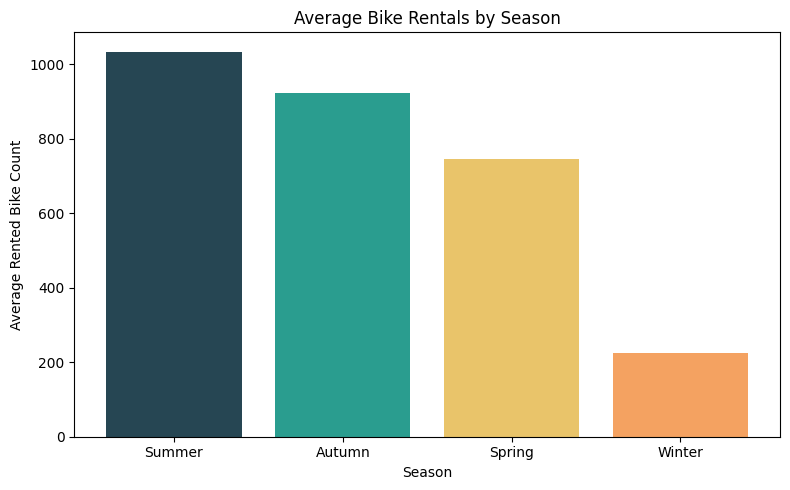

Chart interpretation:
This chart compares average bike rental demand across seasons.
Summer has the highest average demand, while winter has the lowest average demand.
This suggests that seasonal weather strongly affects bike sharing usage.


In [ ]:

seasonAverage = workingBikeData.groupby("season")["rentedBikeCount"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(seasonAverage.index, seasonAverage.values, color=chartColors[:len(seasonAverage)])
plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.savefig("chart1SeasonDemand.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This chart compares average bike rental demand across seasons.")
print("Summer has the highest average demand, while winter has the lowest average demand.")
print("This suggests that seasonal weather strongly affects bike sharing usage.")


# Section 27: Chart 2
# Average rented bikes by month

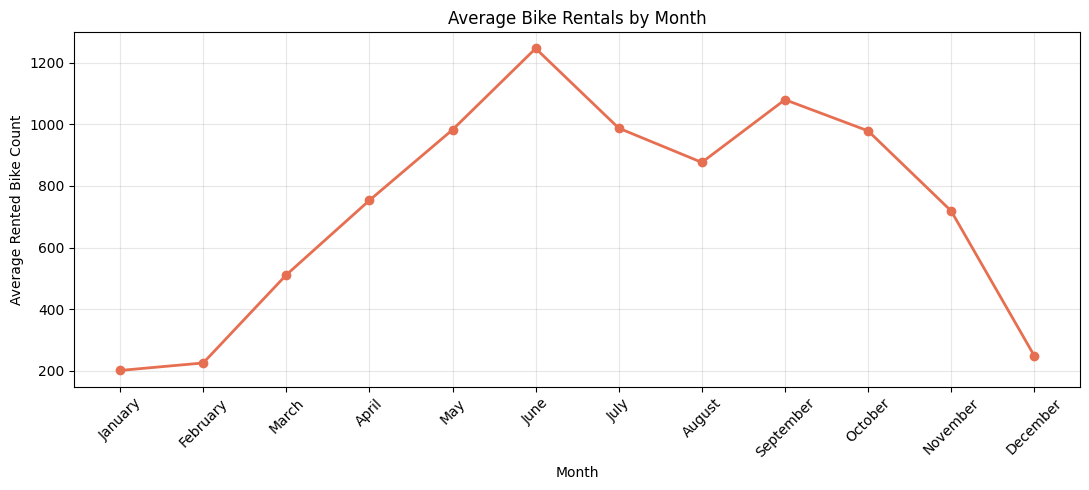

Chart interpretation:
This line chart shows how average rental demand changes from month to month.
Demand rises from winter to warmer months and reaches its highest average in June.
This supports the first analytical question because month is one of the time related factors.


In [ ]:


monthAverage = workingBikeData.groupby(["monthNumber", "monthName"])["rentedBikeCount"].mean().reset_index()
monthAverage = monthAverage.sort_values("monthNumber")

plt.figure(figsize=(11, 5))
plt.plot(monthAverage["monthName"], monthAverage["rentedBikeCount"], marker="o", linewidth=2, color=chartColors[4])
plt.title("Average Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rented Bike Count")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("chart2MonthlyDemand.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This line chart shows how average rental demand changes from month to month.")
print("Demand rises from winter to warmer months and reaches its highest average in June.")
print("This supports the first analytical question because month is one of the time related factors.")

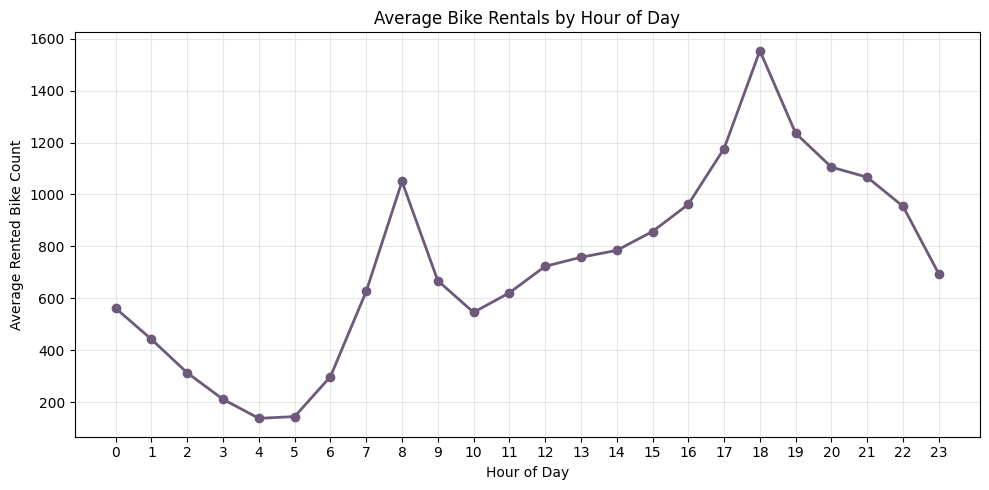

Chart interpretation:
This line chart shows how bike demand changes during the day.
The strongest peak appears at 18:00, which suggests an evening commute pattern.
There is also a smaller morning rise around 8:00, which may be related to work or school travel.


In [ ]:
# ==========================================================
# Section 28: Chart 3
# Average rented bikes by hour
# ==========================================================

hourAverage = workingBikeData.groupby("hour")["rentedBikeCount"].mean().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(hourAverage.index, hourAverage.values, marker="o", linewidth=2, color=chartColors[5])
plt.title("Average Bike Rentals by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("chart3HourlyDemand.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This line chart shows how bike demand changes during the day.")
print("The strongest peak appears at 18:00, which suggests an evening commute pattern.")
print("There is also a smaller morning rise around 8:00, which may be related to work or school travel.")


# Section 29: Chart 4
# Temperature versus rented bike count

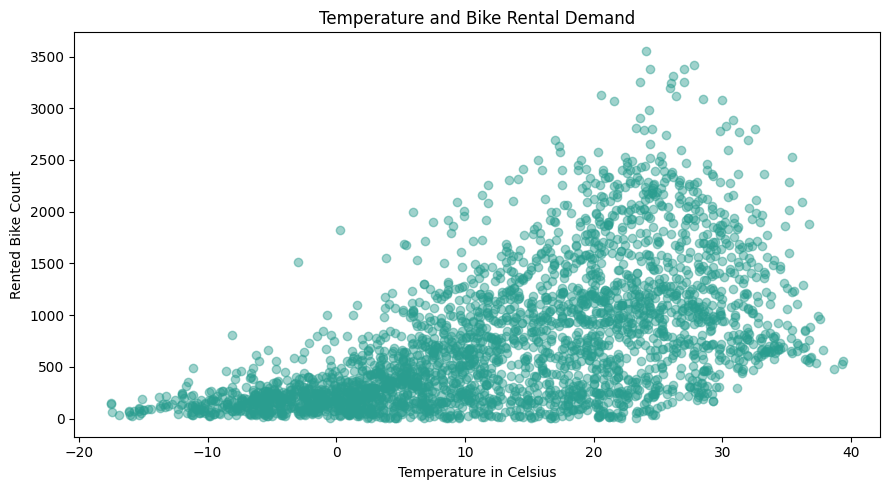

Chart interpretation:
This scatter plot shows the relationship between temperature and bike rental count.
A random sample of up to 3000 records is used to keep the chart readable.
The upward pattern supports the correlation result that warmer temperatures are related to higher rental demand.


In [ ]:

chartSample = workingBikeData.sample(n=min(3000, len(workingBikeData)), random_state=5)

plt.figure(figsize=(9, 5))
plt.scatter(chartSample["temperature"], chartSample["rentedBikeCount"], alpha=0.45, color=chartColors[1])
plt.title("Temperature and Bike Rental Demand")
plt.xlabel("Temperature in Celsius")
plt.ylabel("Rented Bike Count")
plt.tight_layout()
plt.savefig("chart4TemperatureDemand.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This scatter plot shows the relationship between temperature and bike rental count.")
print("A random sample of up to 3000 records is used to keep the chart readable.")
print("The upward pattern supports the correlation result that warmer temperatures are related to higher rental demand.")


# Section 30: Chart 5
# Holiday versus non holiday demand using box plot


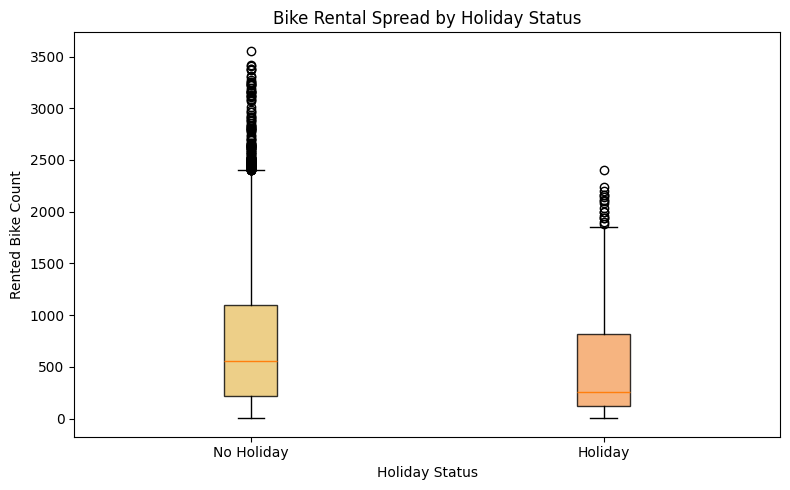

Chart interpretation:
This box plot compares the spread of rental demand on holidays and non holidays.
Non holiday records show a higher median and a wider upper range than holiday records.
This supports the finding that normal working days have stronger bike rental demand.


In [ ]:

holidayBoxData = []
holidayBoxNames = []

for holidayName in workingBikeData["holiday"].unique():
    valuesForHoliday = workingBikeData[workingBikeData["holiday"] == holidayName]["rentedBikeCount"]
    holidayBoxData.append(valuesForHoliday)
    holidayBoxNames.append(holidayName)

plt.figure(figsize=(8, 5))
boxPlot = plt.boxplot(holidayBoxData, patch_artist=True)

for boxNumber in range(len(boxPlot["boxes"])):
    boxPlot["boxes"][boxNumber].set_facecolor(chartColors[boxNumber + 2])
    boxPlot["boxes"][boxNumber].set_alpha(0.8)

plt.xticks(range(1, len(holidayBoxNames) + 1), holidayBoxNames)
plt.title("Bike Rental Spread by Holiday Status")
plt.xlabel("Holiday Status")
plt.ylabel("Rented Bike Count")
plt.tight_layout()
plt.savefig("chart5HolidayBoxplot.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This box plot compares the spread of rental demand on holidays and non holidays.")
print("Non holiday records show a higher median and a wider upper range than holiday records.")
print("This supports the finding that normal working days have stronger bike rental demand.")


# Section 31: Chart 6
# Weather condition demand


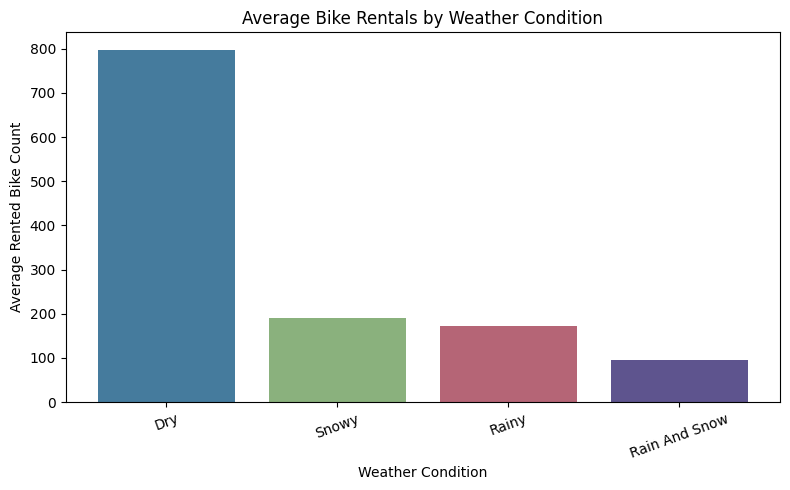

Chart interpretation:
This chart compares demand during dry, rainy, snowy, and mixed weather conditions.
Dry weather has the highest average demand, while rain and snow conditions reduce demand.
This directly supports the weather based analytical question.


In [ ]:

weatherAverage = workingBikeData.groupby("weatherCondition")["rentedBikeCount"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(weatherAverage.index, weatherAverage.values, color=chartColors[6:6 + len(weatherAverage)])
plt.title("Average Bike Rentals by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Rented Bike Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("chart6WeatherConditionDemand.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This chart compares demand during dry, rainy, snowy, and mixed weather conditions.")
print("Dry weather has the highest average demand, while rain and snow conditions reduce demand.")
print("This directly supports the weather based analytical question.")


# Section 32: Chart 7
# Heatmap style chart of demand by season and hour


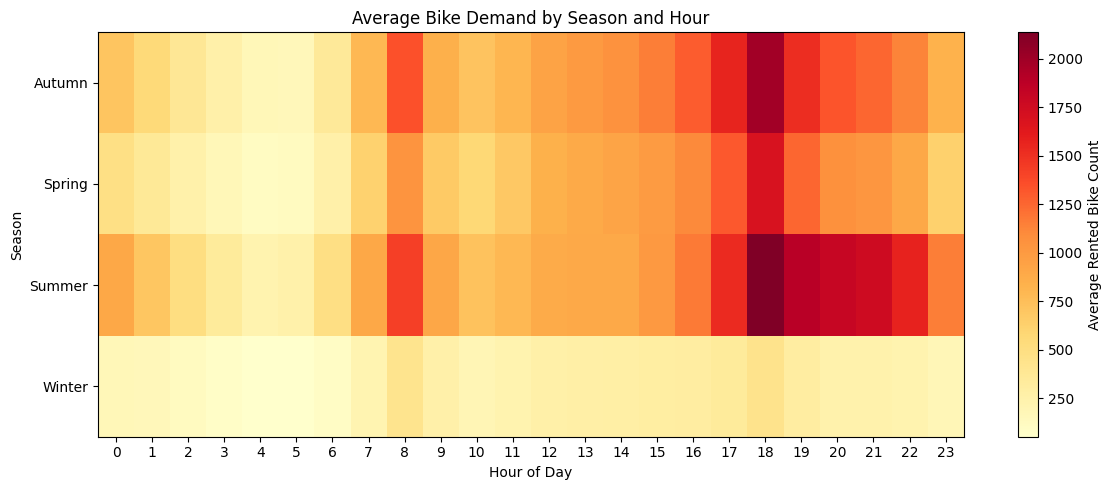

Chart interpretation:
This heatmap style chart shows season and hour together.
Brighter areas show stronger demand, making peak periods easier to identify.
It gives a deeper view than separate season and hour charts because it shows when each season becomes busy.


In [ ]:

seasonHourTable = workingBikeData.pivot_table(
    values="rentedBikeCount",
    index="season",
    columns="hour",
    aggfunc="mean"
)

# imshow is used here as a Matplotlib based heatmap without using seaborn.
plt.figure(figsize=(12, 5))
plt.imshow(seasonHourTable.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Average Rented Bike Count")
plt.title("Average Bike Demand by Season and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Season")
plt.xticks(range(len(seasonHourTable.columns)), seasonHourTable.columns)
plt.yticks(range(len(seasonHourTable.index)), seasonHourTable.index)
plt.tight_layout()
plt.savefig("chart7SeasonHourHeatmap.png", dpi=150)
plt.show()

print("Chart interpretation:")
print("This heatmap style chart shows season and hour together.")
print("Brighter areas show stronger demand, making peak periods easier to identify.")
print("It gives a deeper view than separate season and hour charts because it shows when each season becomes busy.")

## Findings, limitations, and conclusion

This section creates evidence based findings from the actual computed results. These findings can be used in the report and viva, but they should be explained in your own words during presentation.


# Section 33: Evidence based findings


In [ ]:

bestSeason = seasonAverage.idxmax()
bestSeasonValue = seasonAverage.max()

bestMonthRow = monthAverage.sort_values("rentedBikeCount", ascending=False).iloc[0]
bestMonth = bestMonthRow["monthName"]
bestMonthValue = bestMonthRow["rentedBikeCount"]

bestHour = hourAverage.idxmax()
bestHourValue = hourAverage.max()

bestWeather = weatherAverage.idxmax()
bestWeatherValue = weatherAverage.max()

bestWeekendStatus = weekendDemand["mean"].idxmax()
bestWeekendValue = weekendDemand["mean"].max()

bestHolidayStatus = holidayDemand["mean"].idxmax()
bestHolidayValue = holidayDemand["mean"].max()

highestDemandDate = topDemandHours.iloc[0]["date"]
highestDemandHour = topDemandHours.iloc[0]["hour"]
highestDemandCount = topDemandHours.iloc[0]["rentedBikeCount"]

lowestDemandDate = lowestDemandHours.iloc[0]["date"]
lowestDemandHour = lowestDemandHours.iloc[0]["hour"]
lowestDemandCount = lowestDemandHours.iloc[0]["rentedBikeCount"]

veryHighDemandCount = len(veryHighDemand)
highIqrOutlierCount = len(workingBikeData[workingBikeData["iqrDemandFlag"] == "High IQR Outlier"])

findingTable = pd.DataFrame({
    "findingTopic": [
        "Highest average season",
        "Highest average month",
        "Highest average hour",
        "Highest average weather condition",
        "Higher average weekend status",
        "Higher average holiday status",
        "Strongest original weather variable",
        "Custom comfort score correlation",
        "Highest single demand record",
        "Lowest single demand record while service was open",
        "Very high demand z score outlier count",
        "High demand IQR outlier count"
    ],
    "result": [
        bestSeason,
        bestMonth,
        bestHour,
        bestWeather,
        bestWeekendStatus,
        bestHolidayStatus,
        strongestOriginalWeatherVariable,
        "weatherComfortScore",
        str(highestDemandDate.date()) + " at hour " + str(highestDemandHour),
        str(lowestDemandDate.date()) + " at hour " + str(lowestDemandHour),
        veryHighDemandCount,
        highIqrOutlierCount
    ],
    "value": [
        round(bestSeasonValue, 2),
        round(bestMonthValue, 2),
        round(bestHourValue, 2),
        round(bestWeatherValue, 2),
        round(bestWeekendValue, 2),
        round(bestHolidayValue, 2),
        round(strongestOriginalWeatherCorrelation, 4),
        round(comfortScoreCorrelation, 4),
        highestDemandCount,
        lowestDemandCount,
        veryHighDemandCount,
        highIqrOutlierCount
    ]
})

display(findingTable)

print("Main findings:")
print("1. The season with the highest average bike rental demand is", bestSeason, "with an average of", round(bestSeasonValue, 2), "rentals.")
print("2. The month with the highest average demand is", bestMonth, "with an average of", round(bestMonthValue, 2), "rentals.")
print("3. The busiest average hour is", bestHour, "with an average of", round(bestHourValue, 2), "rentals.")
print("4. The weather condition with the highest average demand is", bestWeather, "with an average of", round(bestWeatherValue, 2), "rentals.")
print("5. The higher average weekend status is", bestWeekendStatus, "with an average of", round(bestWeekendValue, 2), "rentals.")
print("6. The higher average holiday status is", bestHolidayStatus, "with an average of", round(bestHolidayValue, 2), "rentals.")
print("7. Among original weather variables, the strongest positive relationship with rentals is", strongestOriginalWeatherVariable, "with correlation", round(strongestOriginalWeatherCorrelation, 4), ".")
print("8. The custom weather comfort score has correlation", round(comfortScoreCorrelation, 4), "with rental count.")
print("9. The highest single demand record happened on", highestDemandDate.date(), "at hour", highestDemandHour, "with", highestDemandCount, "rentals.")
print("10. The lowest single demand record while service was open happened on", lowestDemandDate.date(), "at hour", lowestDemandHour, "with", lowestDemandCount, "rentals.")
print("11. NumPy z score analysis found", veryHighDemandCount, "very high demand outlier records.")
print("12. IQR analysis found", highIqrOutlierCount, "high demand outlier records.")

,findingTopic,result,value
0,Highest average season,Summer,1034.0700
1,Highest average month,June,1245.6800
2,Highest average hour,18,1554.0200
3,Highest average weather condition,Dry,797.2800
4,Higher average weekend status,Weekday,748.1100
5,Higher average holiday status,No Holiday,739.2800
6,Strongest original weather variable,temperature,0.5627
7,Custom comfort score correlation,weatherComfortScore,0.5763
8,Highest single demand record,2018-06-19 at hour 18,3556.0000
9,Lowest single demand record while service was ...,2018-10-06 at hour 10,2.0000


Main findings:
1. The season with the highest average bike rental demand is Summer with an average of 1034.07 rentals.
2. The month with the highest average demand is June with an average of 1245.68 rentals.
3. The busiest average hour is 18 with an average of 1554.02 rentals.
4. The weather condition with the highest average demand is Dry with an average of 797.28 rentals.
5. The higher average weekend status is Weekday with an average of 748.11 rentals.
6. The higher average holiday status is No Holiday with an average of 739.28 rentals.
7. Among original weather variables, the strongest positive relationship with rentals is temperature with correlation 0.5627 .
8. The custom weather comfort score has correlation 0.5763 with rental count.
9. The highest single demand record happened on 2018-06-19 at hour 18 with 3556 rentals.
10. The lowest single demand record while service was open happened on 2018-10-06 at hour 10 with 2 rentals.
11. NumPy z score analysis found 63 very high deman

## Limitations

1. This dataset covers Seoul only, so the results may not apply to every city.
2. The dataset covers about one year, so it cannot fully show long term bike sharing trends.
3. The data does not include station location, user type, public transport conditions, special events, or traffic conditions.
4. Correlation does not prove causation. Weather variables may be related to demand, but they are not the only reason demand changes.
5. Service closed hours were excluded from the main demand analysis because those zero values were caused by system unavailability, not natural customer demand.
6. The weather comfort score is a simple custom feature, not a scientific formula.
7. The scatter plot uses a random sample for readability, so it is a visual summary rather than a display of every record.


# Section 34: Limitations


In [ ]:

print("Limitations:")
print("1. The dataset covers Seoul only, so results may not apply to every city.")
print("2. The data covers about one year, so long term changes across many years cannot be studied here.")
print("3. Some important factors are missing, such as bike station location, user type, public transport strikes, special events, and traffic conditions.")
print("4. Correlation does not prove causation. For example, temperature may be related to demand, but it is not the only reason demand changes.")
print("5. Non functioning hours were excluded from main demand analysis because the service was closed, but this also removes some operational information.")
print("6. The weather comfort score is a simple custom score, so it should be treated as an approximate feature, not a scientific formula.")
print("7. The scatter plot uses a random sample for readability, so it is a visual summary rather than a display of every single record.")

Limitations:
1. The dataset covers Seoul only, so results may not apply to every city.
2. The data covers about one year, so long term changes across many years cannot be studied here.
3. Some important factors are missing, such as bike station location, user type, public transport strikes, special events, and traffic conditions.
4. Correlation does not prove causation. For example, temperature may be related to demand, but it is not the only reason demand changes.
5. Non functioning hours were excluded from main demand analysis because the service was closed, but this also removes some operational information.
6. The weather comfort score is a simple custom score, so it should be treated as an approximate feature, not a scientific formula.
7. The scatter plot uses a random sample for readability, so it is a visual summary rather than a display of every single record.


## Conclusion

This project shows that Seoul bike rental demand is strongly connected with time and weather patterns. Demand is higher in warmer months, peaks clearly in the evening, and is stronger during dry weather. The analysis also shows that normal non holiday periods have higher demand than holidays.

The project uses Pandas for cleaning, grouping, and summarizing data; NumPy for percentiles, z scores, mean, and standard deviation; and Matplotlib for clear visual evidence. Overall, the findings can help a bike sharing operator plan bike availability more effectively during high demand periods.